### NAME: Saurabh Kumar Jha
### SECTION: B
### ROLL. NO. 53

In [1]:
%pip uninstall -y opencv-python
%pip install opencv-python-headless

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Note: you may need to restart the kernel to use updated packages.
  Obtaining dependency information for opencv-python-headless from https://files.pythonhosted.org/packages/9b/21/f6ef335f6e65724aa78b8d792b48d40a48c381715f1e62f5a5049e09d07e/opencv_python_headless-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 7.6 MB/s eta 0:00:000:00:0100:01

[notice] A new release of pip is available: 23.2.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install opencv-python numpy matplotlib

  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/cf/4c/c73f828fdbcd37eaf21d08fa852544a3ca7c2dbb3ea76873d64f2ea413d1/opencv_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl.metadata
  Using cached opencv_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl (73.8 MB)

[notice] A new release of pip is available: 23.2.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Helper function to display images in Jupyter/Codespaces
def display_img(title, img, cmap=None):
    plt.figure(figsize=(6, 4))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

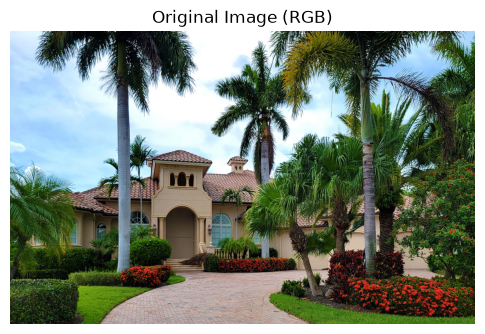

--- Image Properties ---
Dimensions (H x W): 2250 x 3573 pixels
Number of Channels: 3
Total number of pixels: 24117750
Data Type: uint8


In [6]:
# 2. Load the image
image_path = 'sample.jpg'
img_bgr = cv2.imread(image_path)

if img_bgr is None:
    print("Error: Could not read the image. Check the file path.")
else:
    # Convert BGR to RGB for Matplotlib
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Display using Matplotlib
    display_img("Original Image (RGB)", img_rgb)

    # 3. Examine properties
    height, width, channels = img_bgr.shape
    print("--- Image Properties ---")
    print(f"Dimensions (H x W): {height} x {width} pixels")
    print(f"Number of Channels: {channels}")
    print(f"Total number of pixels: {img_bgr.size}")
    print(f"Data Type: {img_bgr.dtype}")

In [7]:
# Save as PNG
cv2.imwrite('output_image.png', img_bgr)

# Save as JPEG with specific quality (0-100)
cv2.imwrite('output_image_compressed.jpg', img_bgr, [int(cv2.IMWRITE_JPEG_QUALITY), 50])

print(f"PNG Size: {os.path.getsize('output_image.png')} bytes")
print(f"JPG (50% Quality) Size: {os.path.getsize('output_image_compressed.jpg')} bytes")
# Observation: PNG is lossless and usually larger; JPEG is lossy and compresses the file size.

PNG Size: 16280978 bytes
JPG (50% Quality) Size: 1107006 bytes


In [9]:
# Load the newly created JPG image
saved_jpg = cv2.imread('output_image_compressed.jpg')

# Check if the image loaded successfully
if saved_jpg is not None:
    # Extract height, width, and channels
    h, w, c = saved_jpg.shape
    
    # Standard resolution is usually written as Width x Height
    print(f"Saved JPG Resolution: {w} x {h} pixels")
else:
    print("Could not find 'output_image_compressed.jpg'. Check the file name.")

Saved JPG Resolution: 3573 x 2250 pixels


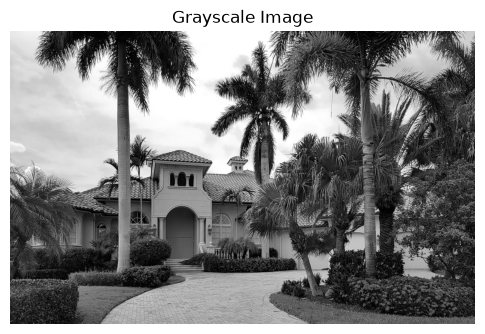

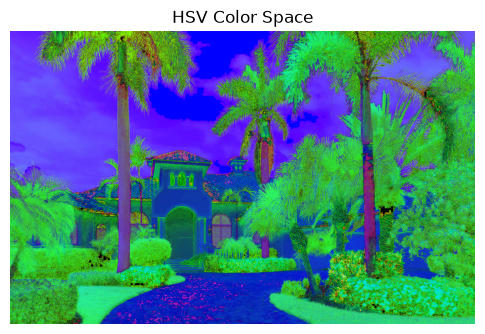

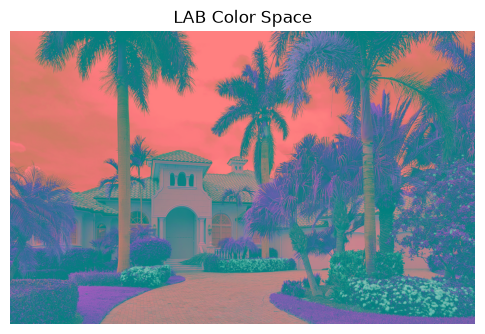

In [10]:
# Convert to Grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
display_img("Grayscale Image", img_gray, cmap='gray')

# Convert to HSV (Hue, Saturation, Value)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
display_img("HSV Color Space", img_hsv)

# Convert to LAB (Lightness, A-color, B-color)
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
display_img("LAB Color Space", img_lab)

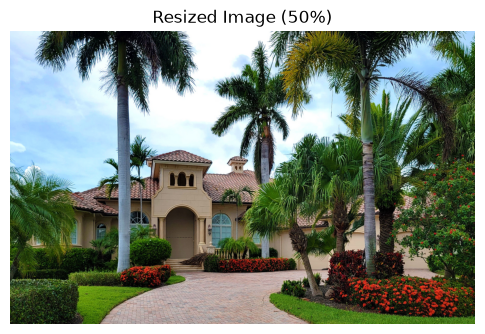

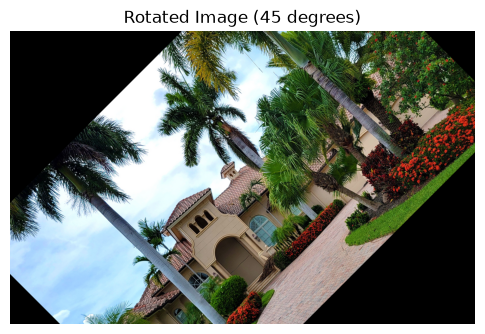

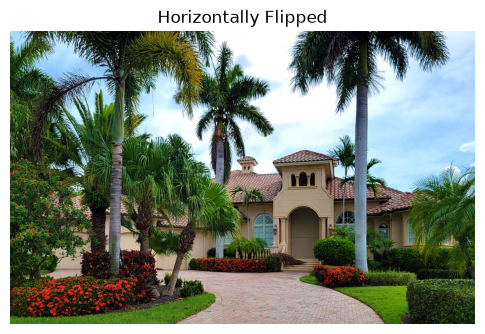

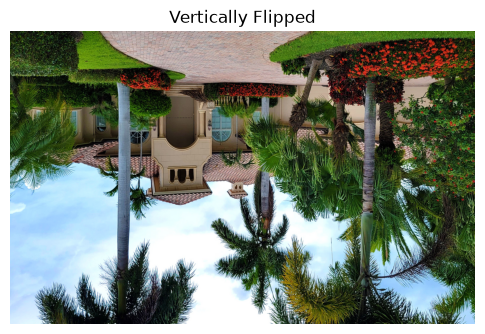

In [13]:
# 1. Resizing (Shrink to 50%)
resized_img = cv2.resize(img_rgb, (width // 2, height // 2))
display_img("Resized Image (50%)", resized_img)

# 2. Rotation (Rotate 45 degrees counter-clockwise)
center = (width // 2, height // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1.0) # center, angle, scale
rotated_img = cv2.warpAffine(img_rgb, rotation_matrix, (width, height))
display_img("Rotated Image (45 degrees)", rotated_img)

# 3. Flipping (Horizontal flip: 1)
hflipped_img = cv2.flip(img_rgb, 1) 
display_img("Horizontally Flipped", hflipped_img)

# 4. Flipping (Vertical flip: 0)
vflipped_img = cv2.flip(img_rgb, 0) 
display_img("Vertically Flipped", vflipped_img)

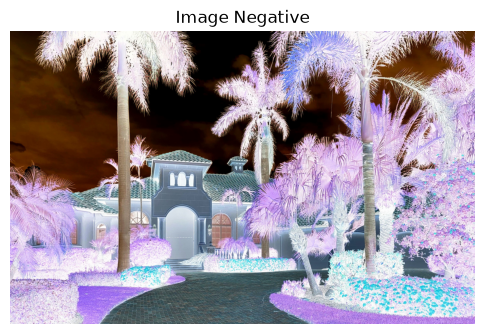

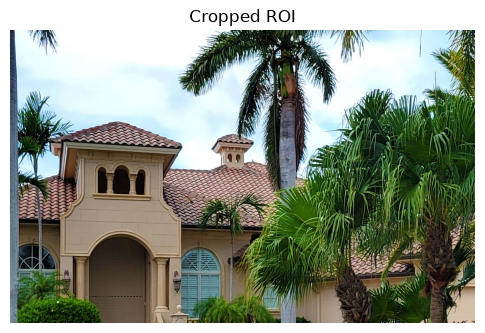

In [14]:
# 7. Generate Negative (Invert pixel values: 255 - pixel)
img_negative = cv2.bitwise_not(img_rgb)
display_img("Image Negative", img_negative)

# 8. Crop a Region of Interest (ROI)
# Slicing the numpy array: image[startY:endY, startX:endX]
start_y, end_y = height // 4, (height // 4) * 3
start_x, end_x = width // 4, (width // 4) * 3

img_roi = img_rgb[start_y:end_y, start_x:end_x]
display_img("Cropped ROI", img_roi)


## 10: Observations and Significance in Computer Vision

### Part 1: Key Observations

* **File Formats and Compression:** When saving the image, the resolution (width × height) remained identical for both PNG and JPEG formats. However, setting the JPEG quality parameter significantly reduced the file size on the disk. This demonstrates lossy compression, where minor visual details are discarded to save space, unlike PNG which utilizes lossless compression.
* **Color Space Conversions:**
* Converting to **Grayscale** collapsed the 3-channel (RGB) image into a single channel, reducing the total amount of data by a third.
* Converting to **HSV** (Hue, Saturation, Value) separated the color information (Hue) from the lighting intensity (Value), making the image look distorted to the human eye but mathematically organizing the color data.


* **Geometric Transformations:** Operations like resizing, rotating, and flipping manipulate the spatial coordinates of the pixels. For instance, resizing physically changes the dimensions of the NumPy array, while flipping (using code `1` for horizontal and `0` for vertical) mirrors the matrix data along an axis.
* **Image Negative and ROI:** Generating the negative inverted the pixel intensities (subtracting the current value from 255). Cropping a Region of Interest (ROI) successfully extracted a smaller subset of the original pixel matrix, isolating a specific area and discarding the rest.

### Part 2: Significance of Preprocessing in Computer Vision

Before feeding images into advanced computer vision algorithms (like facial recognition, object detection, or neural networks), these fundamental preprocessing steps are strictly required for the following reasons:

1. **Computational Efficiency:** Machine learning models require immense processing power. By converting images to grayscale or cropping them to a specific ROI, we drastically reduce the amount of redundant data the computer has to process, speeding up inference times.
2. **Standardizing Input Data:** Neural networks require fixed-size inputs. If a dataset contains images of varying dimensions, the **resizing** operation is mandatory to ensure uniform matrices before training begins.
3. **Robustness and Data Augmentation:** Real-world data is messy. Objects can be upside down, tilted, or mirrored. By artificially applying **rotations and flips** to our dataset, we can create more training examples. This prevents the AI from memorizing exact pixel locations and teaches it to recognize an object regardless of its orientation.
4. **Isolating Features:** Color spaces like **HSV** are crucial for tasks like lane-tracking in autonomous driving or tracking a colored ball in robotics. Because HSV separates the lighting from the color, the algorithm can still detect a "red" stop sign accurately even if it is sitting in a dark shadow, which is highly difficult to do using standard RGB.

### NAME: ALOK KUMAR MAVI
### SECTION: B
### ROLL. NO. 05

# Questions

## 1. Why is data preprocessing considered one of the most important phases in data analytics?

Data preprocessing is important because real-world data is often **incomplete, inconsistent, noisy, or duplicated**. Preprocessing improves the quality and reliability of the dataset before visualization or machine learning.

It includes:

* Handling missing values
* Removing duplicate records
* Correcting inconsistent data
* Detecting and treating outliers
* Encoding categorical variables
* Normalizing or standardizing numerical data

Good preprocessing helps produce **more accurate, reliable, and meaningful analytical results**.

---

## 2. Explain different methods of handling missing values with suitable examples.

Missing values can be handled using several methods:

### Mean Imputation

Replace a missing numerical value with the mean of the column.

> **Example:** If the ages are `20, 25, NaN, 35`, the missing value can be replaced by:
> `(20 + 25 + 35) / 3 = 26.67`

### Median Imputation

Replace the missing value with the median. This is useful when the data contains outliers.

> **Example:** For ages `20, 22, 25, 30, 80`, the median is `25`.

### Mode Imputation

Replace a missing categorical value with the most frequently occurring value.

> **Example:** If Gender values are `Male, Female, Male, NaN`, the missing value can be replaced with `Male`.

### Row or Column Removal

Rows containing missing values can be removed when only a small number of records are affected. A column may also be removed if it has a very large number of missing values.

These methods help make the dataset suitable for further analysis.

---

## 3. Differentiate between Label Encoding and One-Hot Encoding.

| Label Encoding | One-Hot Encoding |
| --- | --- |
| Converts categories into numerical labels. | Creates separate binary columns for each category. |
| Each category gets a unique integer. | Each category is represented using 0 or 1. |
| Example: Male = `0`, Female = `1` | Example: Gender_Male = `1`/`0`, Gender_Female = `1`/`0` |
| Uses fewer columns. | Creates more columns. |
| Can sometimes imply an artificial order. | Does not imply an order. |

> **Example for `Color = Red, Blue, Green`:**
> * **Label Encoding:** `Red = 0`, `Blue = 1`, `Green = 2`
> * **One-Hot Encoding:** `Red → [1,0,0]`, `Blue → [0,1,0]`, `Green → [0,0,1]`
> 
> 

The experiment specifically identifies both Label Encoding and One-Hot Encoding as methods for converting categorical variables into numerical form.

---

## 4. What are outliers? How can they affect analytical results?

**Outliers** are data values that are unusually far from the majority of observations.

> **Example:** If most employee salaries are between ₹30,000 and ₹80,000 but one value is ₹10,00,000, that extreme value is an outlier.

### Effects of outliers:

* Distort the **mean**
* Increase the **standard deviation**
* Affect correlations and statistical relationships
* Can reduce machine learning model performance
* May lead to misleading analytical conclusions

Outliers can be detected using methods such as **Box Plots** and the **IQR (Interquartile Range)** method.

---

## 5. Explain the difference between normalization and standardization.

### Normalization

Normalization scales values to a fixed range, commonly **0 to 1**. It is useful when attributes have very different ranges.

A common formula is:


$$X' = \frac{X-X_{min}}{X_{max}-X_{min}}$$

### Standardization

Standardization transforms data so that it centers around the mean with a standard unit of variance. It has approximately:

* **Mean = 0**
* **Standard deviation = 1**

The formula is:


$$Z = \frac{X-\mu}{\sigma}$$

### Key Differences

| Normalization | Standardization |
| --- | --- |
| Usually scales data to a fixed range (0–1). | Centers data around a mean of 0. |
| Depends on minimum and maximum values. | Depends on the mean and standard deviation. |
| Useful when a strict boundary is required. | Useful for many statistical and ML techniques. |

The experiment lists normalization and standardization as key techniques for bringing numerical attributes to a common scale.

---

## 6. Why should duplicate records be removed before analysis?

Duplicate records represent the same observation more than once. Keeping them can cause certain observations to receive **extra weight** in the analysis.

Removing duplicates:

* Prevents biased results
* Improves data consistency
* Avoids incorrect counts and statistics
* Helps machine learning models learn from unique observations

Therefore, duplicate records should generally be detected and removed before analysis.

---

## 7. What is feature engineering? Give two practical examples.

**Feature engineering** is the process of creating new, useful attributes from existing data to improve analysis or machine learning performance.

### Example 1: Family Size

In the Titanic dataset, a new feature can be created by combining existing columns:


$$\text{Family Size} = \text{Siblings/Spouses} + \text{Parents/Children} + 1$$

### Example 2: Age Group

A continuous `Age` variable can be converted into categorical buckets such as:

* Child
* Young Adult
* Adult
* Senior

Feature engineering makes existing information more meaningful and useful for models to interpret.

---

## 8. Which preprocessing techniques would you apply to the IBM HR Employee Attrition dataset and why?

For the **IBM HR Employee Attrition dataset**, the following preprocessing techniques should be applied:

1. **Handle missing values:** Replace or remove missing data appropriately to maintain integrity.
2. **Remove duplicate records:** Prevent repeated employee information from skewing metrics.
3. **Standardize categorical values:** Ensure text categories are consistent (e.g., standardizing capitalization).
4. **Encode categorical variables:** Use Label Encoding or One-Hot Encoding so ML models can process text data.
5. **Detect outliers:** Use Box Plots and the IQR method for numerical attributes like salary or years at the company.
6. **Normalize or standardize numerical features:** Bring variables such as income and age to comparable scales.
7. **Feature engineering:** Create useful variables such as income categories, tenure blocks, or age groups.

These techniques improve data quality and prepare the dataset for reliable analysis.

---

## 9. How does poor-quality data affect machine learning model performance?

Poor-quality data can significantly reduce machine learning performance. It can:

* Reduce model **accuracy**
* Introduce **bias**
* Cause incorrect patterns to be learned
* Increase prediction errors
* Make the model less reliable on new, unseen data

For example, missing values, duplicate records, incorrect categorical values, and extreme outliers can cause the model to learn misleading relationships. Proper preprocessing is essential for producing a **reliable and effective machine learning model**.

---

## 10. Name any three Python libraries commonly used for data preprocessing.

Three commonly used Python libraries are:

1. **Pandas:** For data loading, cleaning, manipulation, and handling missing values.
2. **NumPy:** For numerical operations and fast array-based computations.
3. **Scikit-learn:** For preprocessing techniques such as encoding, normalization, standardization, and imputation.

*(The experiment also lists Matplotlib and Seaborn among the required Python libraries, which are heavily used during the exploratory data analysis phase of preprocessing).*